# 实验四
### 1.对于下表中的数据，对1990年-2005年内的数据建立人口自然增长率对于国民总收入、CPI增长率和人均GDP的三元线性回归模型。

In [7]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] 

# 1. 整理数据 (1990-2005年)
data = {
    'Year': [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005],
    # y: 人口自然增长率 (%)
    'y_PopGrowth': [14.39, 12.98, 11.6, 11.45, 11.21, 10.55, 10.42, 10.06, 9.14, 8.18, 7.58, 6.95, 6.45, 6.01, 5.87, 5.89],
    # x1: 国民总收入 (亿元)
    'x1_GNI': [18718, 21826, 26937, 35260, 48108, 59811, 70142, 78061, 83024, 88479, 98000, 108048, 119086, 135174, 159587, 184089],
    # x2: CPI 增长率 (%)
    'x2_CPI': [3.1, 3.4, 6.4, 14.7, 24.1, 17.1, 8.3, 2.8, -0.8, -1.4, 0.4, 0.7, -0.8, 1.2, 3.9, 1.8],
    # x3: 人均 GDP (元)
    'x3_GDP_per_capita': [1644, 1893, 2311, 2998, 4044, 4846, 5846, 6420, 6796, 7158, 7858, 8622, 9358, 10542, 12336, 14040]
}

# 转换为 DataFrame
df = pd.DataFrame(data)

# 2. 准备变量
# Y 是因变量
y = df['y_PopGrowth']
# X 是自变量
X = df[['x1_GNI', 'x2_CPI', 'x3_GDP_per_capita']]

# 3. 添加常数项 (截距)
# statsmodels.OLS 默认不包含截距项，我们用 add_constant 手动添加
X_with_const = sm.add_constant(X)

# 4. 建立并拟合 OLS (Ordinary Least Squares) 模型
model = sm.OLS(y, X_with_const)
results = model.fit()

# 5. 打印回归结果摘要
print("三元线性回归模型结果摘要")
print(results.summary())

三元线性回归模型结果摘要
                            OLS Regression Results                            
Dep. Variable:            y_PopGrowth   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     45.26
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           8.11e-07
Time:                        23:02:49   Log-Likelihood:                -17.930
No. Observations:                  16   AIC:                             43.86
Df Residuals:                      12   BIC:                             46.95
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                14.9

d:\autumn\My_Envir\project\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)


### 4. 下载UCI中wine数据集：所下载数据可以用txt打开，其中每一行数据为一种Wine的记录，每条记录包含14个维度，其中第一维为该Wine类别，后面13维为具体的Wine属性。请基于所有的178个Wine样本对Wine的13个维度进行PCA降维分析，将贡献率之和大于90%的成分提取，并将原13维属性数据映射为新数据。

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1. 加载数据 ---

file_path = r'D:\\autumn\\CS_Experiment\\DataAnlysis_Experiment\\wine\\wine.data'

try:
    # UCI 数据集通常没有表头 (header=None)
    df = pd.read_csv(file_path, header=None)
    print(f"文件 '{file_path}' 读取成功！")

except FileNotFoundError:
    print(f"错误：未找到文件 '{file_path}'。")
    print("请再次检查路径和文件名是否完全正确。")
except Exception as e:
    print(f"发生其他错误: {e}")

# --- 2. 分离特征 (X) 和标签 (y) ---

# 第 1 维 (索引 0) 是类别标签
y = df[0]

# 后面 13 维 (索引 1 到 13) 是属性特征
X = df.loc[:, 1:]

# --- 3. 标准化数据 ---

# PCA 对数据的尺度非常敏感（即方差大小）
# 在执行 PCA 之前，必须对特征进行标准化（均值为0，方差为1）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 4. 执行 PCA 分析 ---

# 关键步骤：设置 n_components=0.9
# sklearn 将自动选择能解释 90% (0.9) 以上方差所需的最少主成分数量
print("正在执行 PCA，目标累计贡献率 > 90% ...")
pca = PCA(n_components=0.9)

# 拟合数据并进行转换（映射）
X_new = pca.fit_transform(X_scaled)

# --- 5. 打印分析结果 ---

print("\n--- PCA 降维分析结果 ---")
print(f"原始数据维度: {X.shape}")
print(f"标准化后数据维度: {X_scaled.shape}")
print(f"降维后新数据维度: {X_new.shape}")

print("--------------------------")
# pca.n_components_ 会告诉我们它自动选择了多少个成分
print(f"自动选择的主成分数量: {pca.n_components_}")

# pca.explained_variance_ratio_ 存储了每个主成分的贡献率
print(f"各主成分的贡献率: {pca.explained_variance_ratio_}")

# 计算并打印累计贡献率
total_variance = np.sum(pca.explained_variance_ratio_)
print(f"累计贡献率: {total_variance:.4f} (即 {total_variance*100:.2f}%)")

print("\n--- 映射后的新数据 (前 5 行) ---")
# 设置 numpy 打印选项以便于阅读
np.set_printoptions(precision=4, suppress=True)
print(X_new[:5])

文件 'D:\\autumn\\CS_Experiment\\DataAnlysis_Experiment\\wine\\wine.data' 读取成功！
正在执行 PCA，目标累计贡献率 > 90% ...

--- PCA 降维分析结果 ---
原始数据维度: (178, 13)
标准化后数据维度: (178, 13)
降维后新数据维度: (178, 8)
--------------------------
自动选择的主成分数量: 8
各主成分的贡献率: [0.362  0.1921 0.1112 0.0707 0.0656 0.0494 0.0424 0.0268]
累计贡献率: 0.9202 (即 92.02%)

--- 映射后的新数据 (前 5 行) ---
[[ 3.3168  1.4435 -0.1657 -0.2156  0.693   0.2239  0.5964 -0.0651]
 [ 2.2095 -0.3334 -2.0265 -0.2914 -0.2577  0.9271  0.0538 -1.0244]
 [ 2.5167  1.0312  0.9828  0.7249 -0.251  -0.5493  0.4242  0.3442]
 [ 3.7571  2.7564 -0.1762  0.568  -0.3118 -0.1144 -0.3833 -0.6436]
 [ 1.0089  0.8698  2.0267 -0.4098  0.2985  0.4065  0.4441 -0.4167]]


### 3.（1）随机生成均值、方差各不相同，且相互之间有少量交叉的3个类，每类30个样本，用不同的颜色进行展示。
### 3. （2）通过keamns聚类分析，将所有的数据分成3类、4类、5类，每一类用不同颜色示。共形成4张图。

d:\autumn\My_Envir\project\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


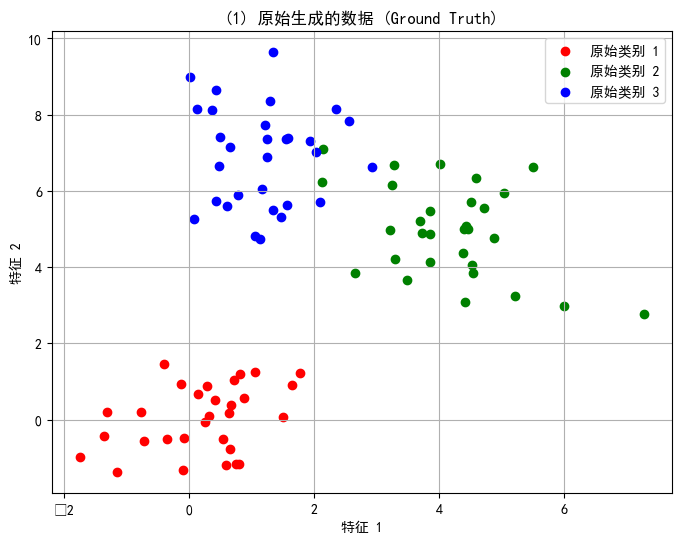


--- 正在执行 K-Means 聚类 (K=[3, 4, 5]) ---


Exception in thread Thread-4:
Traceback (most recent call last):
  File "d:\autumn\My_Envir\project\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "d:\autumn\My_Envir\project\lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "d:\autumn\My_Envir\project\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "d:\autumn\My_Envir\project\lib\subprocess.py", line 1495, in _readerthread
    buffer.append(fh.read())
  File "d:\autumn\My_Envir\project\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte
d:\autumn\My_Envir\project\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause ra

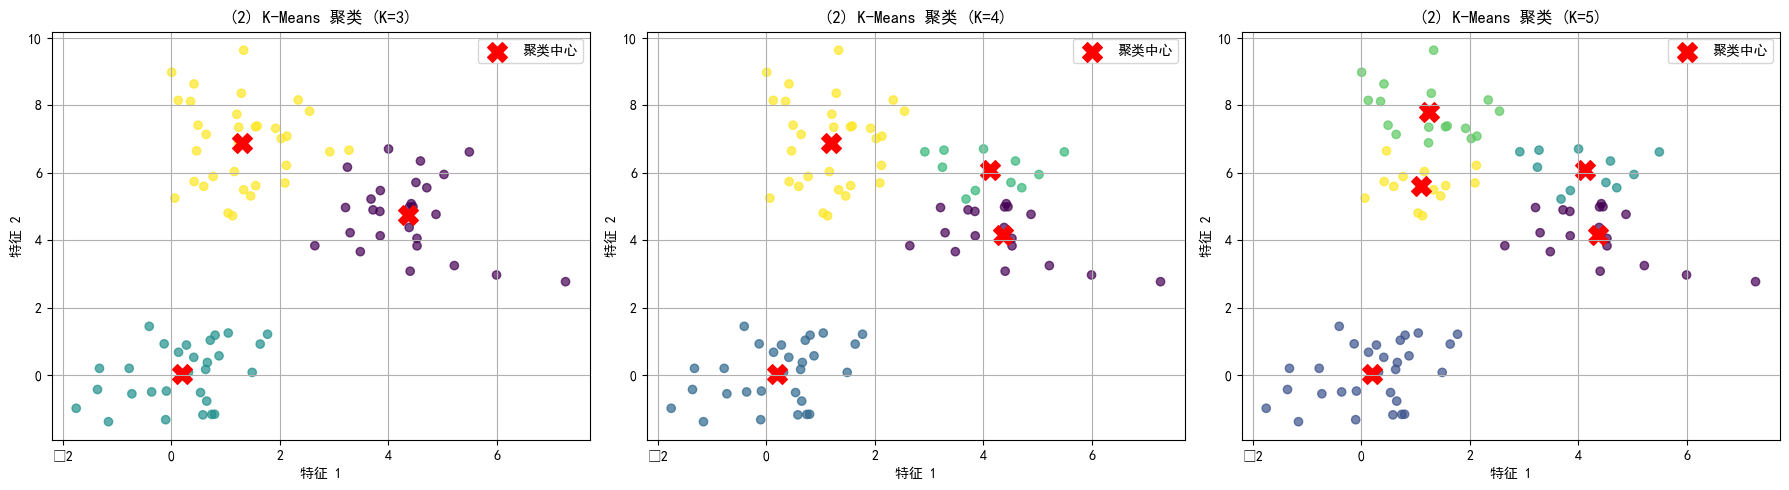

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- (1) 生成数据 ---

# 为了让结果可复现，设置一个随机种子
np.random.seed(42)

n_samples = 30  # 每类的样本数

# 定义 3 个类的均值和协方差矩阵
# 均值不同，协方差矩阵（控制方差和形状）也不同
mean1 = [0, 0]
cov1 = [[1, 0.5], [0.5, 1]]  # 倾斜的椭圆

mean2 = [4, 5]
cov2 = [[1.5, -0.7], [-0.7, 1.5]] # 另一个方向倾斜的椭圆

mean3 = [1, 7]
cov3 = [[0.5, 0], [0, 2]]   # 窄高的椭圆

# 生成数据
class1 = np.random.multivariate_normal(mean1, cov1, n_samples)
class2 = np.random.multivariate_normal(mean2, cov2, n_samples)
class3 = np.random.multivariate_normal(mean3, cov3, n_samples)

# 将所有数据合并到一个数组中，用于后续聚类
# X 是一个 (90, 2) 的数组
X = np.vstack((class1, class2, class3))

# --- 可视化 (1)：展示原始的 3 个类 ---
plt.figure(figsize=(8, 6))
plt.scatter(class1[:, 0], class1[:, 1], c='r', label='原始类别 1')
plt.scatter(class2[:, 0], class2[:, 1], c='g', label='原始类别 2')
plt.scatter(class3[:, 0], class3[:, 1], c='b', label='原始类别 3')
plt.title('(1) 原始生成的数据 (Ground Truth)')
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.legend()
plt.grid(True)
plt.show()


# --- (2) K-Means 聚类分析 ---

# 我们要分析的 K 值
k_values = [3, 4, 5]

# 创建一个 1x3 的子图网格，用于并排显示 K=3, 4, 5 的结果
# (figsize可以根据您的屏幕调整)
fig, axes = plt.subplots(1, len(k_values), figsize=(18, 5))

print(f"\n--- 正在执行 K-Means 聚类 (K={k_values}) ---")

for i, k in enumerate(k_values):
    # 创建 KMeans 模型
    # n_init=10 是为了防止陷入局部最优解，'auto'是新版本的默认值
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    # 拟合数据并预测标签
    labels = kmeans.fit_predict(X)
    
    # 获取聚类中心
    centers = kmeans.cluster_centers_
    
    # --- 可视化 (2)：在对应的子图上绘图 ---
    ax = axes[i]
    # 使用 labels 作为颜色，cmap='viridis' 是一种常用的颜色映射
    scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7)
    
    # 标出聚类中心（用红色大 'X'）
    ax.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='聚类中心')
    
    ax.set_title(f'(2) K-Means 聚类 (K={k})')
    ax.set_xlabel('特征 1')
    ax.set_ylabel('特征 2')
    ax.legend()
    ax.grid(True)

# 调整布局并显示K-Means结果图
plt.tight_layout()
plt.show()

### 4. 随机生成完全不交叉的2个类，每个类包含30个样本，用SVM进行分类和返回所有支撑向量，并以合适方式进行Figure展示。

--- SVM 支撑向量 (共 3 个) ---
[[1.2262 1.1755]
 [0.783  1.7927]
 [5.3495 4.619 ]]


d:\autumn\My_Envir\project\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


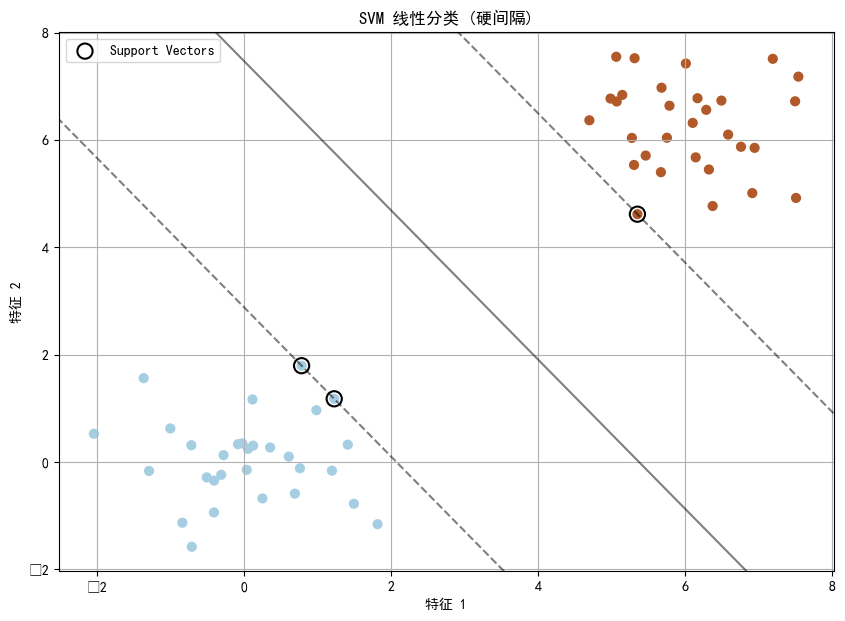

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs

# --- (1) 生成完全不交叉的 2 个类 ---

# n_samples=[30, 30] 确保每类30个样本
# centers=[[0, 0], [6, 6]] 两个中心点相距很远
# cluster_std=0.8 控制簇内方差，确保不重叠
# random_state=0 保证每次运行结果一致
X, y = make_blobs(n_samples=[30, 30], 
                  centers=[[0, 0], [6, 6]], 
                  cluster_std=0.8, 
                  random_state=0)


# --- (2) 训练 SVM 模型 ---

# 我们使用 C=1000 (一个很大的值) 来强制执行“硬间隔”(Hard Margin)
# 因为我们知道数据是完全可分的
clf = svm.SVC(kernel='linear', C=1000)
clf.fit(X, y)


# --- (3) 返回所有支撑向量 ---

# 从拟合后的模型中获取支撑向量
support_vectors = clf.support_vectors_

print(f"--- SVM 支撑向量 (共 {len(support_vectors)} 个) ---")
print(support_vectors)


# --- (4) 以合适方式进行 Figure 展示 ---

plt.figure(figsize=(10, 7))

# 1. 绘制所有数据点，用颜色区分
# c=y 表示颜色根据标签 y (0 或 1) 来决定
# cmap=plt.cm.Paired 是一种清晰的颜色方案
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Paired)

# 2. 绘制支撑向量
# 支撑向量被一个大的、黑边的、无填充的圆圈高亮显示
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], 
            s=120, facecolors='none', edgecolors='k', 
            linewidths=1.5, label='Support Vectors')

# 3. 绘制决策边界和间隔 (Margins)
# 这是绘制 SVM 边界的标准方法
ax = plt.gca() # 获取当前绘图轴
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# 创建网格来评估模型
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# decision_function() 返回每个点到决策边界的"距离"
Z = clf.decision_function(xy).reshape(XX.shape)

# 绘制决策边界 (Z=0) 和间隔 (Z=-1, Z=1)
# levels=[-1, 0, 1] 分别对应 间隔、决策边界、间隔
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# --- 图表美化 ---
plt.title('SVM 线性分类 (硬间隔)')
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.legend()
plt.grid(True)
plt.show()